In [1]:
import numpy as np 
import pandas as pd
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('Datasets/train.csv',usecols=['Age','Fare','Survived'])
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [3]:
df.isnull().sum()   

Survived      0
Age         177
Fare          0
dtype: int64

In [4]:
X=df.drop('Survived',axis=1)
y=df['Survived']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42) 

In [6]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [7]:
X_train['Age_imputed'][X_train['Age_imputed'].isnull()]

29    NaN
55    NaN
533   NaN
495   NaN
468   NaN
       ..
330   NaN
214   NaN
466   NaN
121   NaN
270   NaN
Name: Age_imputed, Length: 140, dtype: float64

In [8]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([59.  , 24.  , 23.  , 45.5 , 34.  , 47.  ,  0.92, 33.  , 29.  ,
       24.  ,  1.  , 17.  , 18.  , 22.  , 19.  , 19.  , 18.  , 39.  ,
       39.  , 16.  , 30.  ,  8.  , 25.  , 22.  , 46.  , 30.  , 31.  ,
       36.  , 47.  , 38.  , 19.  , 24.  ,  3.  , 29.  , 30.  , 65.  ,
        3.  , 29.  , 42.  , 18.  , 18.  , 22.  , 30.  , 27.  , 18.  ,
       34.  , 44.  , 22.  , 27.  , 50.  , 48.  , 26.  , 32.  , 45.  ,
       21.  , 32.5 ,  8.  , 28.  , 24.  , 58.  , 18.  , 37.  , 50.  ,
       45.  , 16.  , 21.  , 27.  , 28.  , 26.  , 16.  , 51.  , 33.  ,
        2.  , 56.  , 35.  , 22.  , 39.  , 19.  , 35.  , 19.  , 36.  ,
       21.  , 33.  , 50.  , 31.  , 22.  , 44.  ,  9.  , 16.  ,  1.  ,
       62.  , 19.  , 26.  , 29.  , 56.  , 28.  ,  1.  , 54.  , 28.  ,
       19.  , 11.  , 31.  , 32.  , 28.5 , 24.  , 42.  , 21.  , 40.  ,
       58.  , 48.  , 24.  , 20.  , 16.  ,  1.  , 27.  ,  3.  , 15.  ,
       21.  , 39.  , 28.  , 29.  , 20.  , 43.  , 31.  , 26.  , 46.  ,
       25.  , 28.  ,

In [9]:
X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
X_test['Age_imputed'][X_test['Age_imputed'].isnull()] = X_test['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

C:\Users\omdon\AppData\Local\Temp\ipykernel_17136\1252176479.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
C

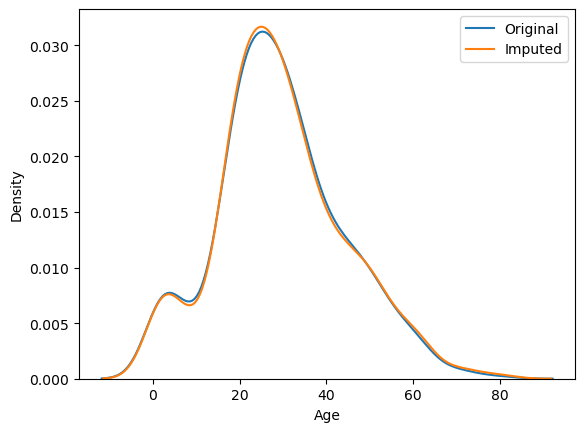

In [10]:

sns.kdeplot(X_train['Age'],label='Original')
sns.kdeplot(X_train['Age_imputed'],label = 'Imputed')

plt.legend()
plt.show()

In [11]:
print("Original variable variance:",X_train['Age'].var())
print("Imputed variable variance:",X_train['Age_imputed'].var())

Original variable variance: 210.2517072477438
Imputed variable variance: 217.18556038318383


In [12]:
X_train[['Fare','Age','Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2700.831981,71.580633,48.518135
Age,71.580633,210.251707,210.251707
Age_imputed,48.518135,210.251707,217.185560


<Axes: >

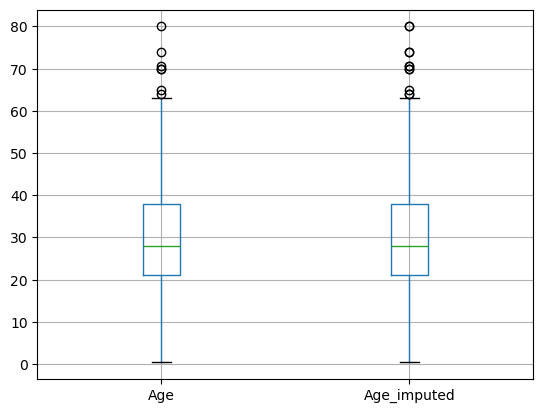

In [13]:
X_train[['Age','Age_imputed']].boxplot()

In [14]:
data = pd.read_csv('Datasets/train2.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])

In [15]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [16]:
data.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [17]:
A=data
B=data['SalePrice']

In [18]:
A_train, A_test, B_train, B_test = train_test_split(A,B, test_size=0.2, random_state=42)

In [19]:
A_train['GarageQual_imputed'] = A_train['GarageQual']
A_test['GarageQual_imputed'] = A_test['GarageQual']

A_train['FireplaceQu_imputed'] = A_train['FireplaceQu']
A_test['FireplaceQu_imputed'] = A_test['FireplaceQu']

In [20]:
A_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
61,NaN,TA,101000,TA,NaN
864,NaN,TA,250580,TA,NaN
463,Gd,TA,188700,TA,Gd
856,NaN,TA,147000,TA,NaN
944,Gd,TA,137500,TA,Gd


In [21]:
A_train['GarageQual_imputed'][A_train['GarageQual_imputed'].isnull()] = A_train['GarageQual'].dropna().sample(A_train['GarageQual'].isnull().sum()).values
A_train['FireplaceQu_imputed'][A_train['FireplaceQu_imputed'].isnull()] = A_train['FireplaceQu'].dropna().sample(A_train['FireplaceQu'].isnull().sum()).values
A_test['GarageQual_imputed'][A_test['GarageQual_imputed'].isnull()] = A_test['GarageQual'].dropna().sample(A_test['GarageQual'].isnull().sum()).values
A_test['FireplaceQu_imputed'][A_test['FireplaceQu_imputed'].isnull()] = A_test['FireplaceQu'].dropna().sample(A_test['FireplaceQu'].isnull().sum()).values

C:\Users\omdon\AppData\Local\Temp\ipykernel_17136\2142137628.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  A_train['GarageQual_imputed'][A_train['GarageQual_imputed'].isnull()] = A_train['GarageQual'].dropna().sample(A_train['GarageQua

In [22]:

temp = pd.concat(
        [
            A_train['GarageQual'].value_counts() / len(A_train['GarageQual'].dropna()),
            A_train['GarageQual_imputed'].value_counts() / len(A_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']
temp

,original,imputed
TA,0.951087,0.952911
Fa,0.032609,0.031678
Gd,0.011775,0.011130
Ex,0.002717,0.002568
Po,0.001812,0.001712


In [23]:
temp = pd.concat(
        [
            A_train['FireplaceQu'].value_counts() / len(A_train['FireplaceQu'].dropna()),
            A_train['FireplaceQu_imputed'].value_counts() / len(A_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']
temp

,original,imputed
Gd,0.491143,0.489726
TA,0.405797,0.404966
Fa,0.043478,0.045377
Ex,0.033816,0.034247
Po,0.025765,0.025685


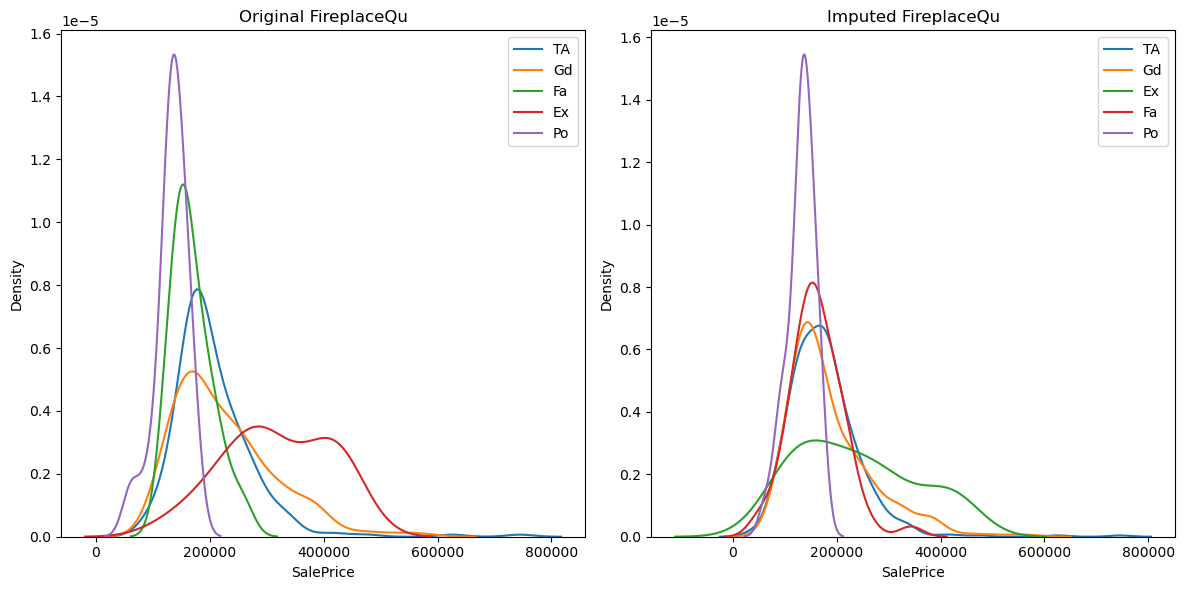

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Original feature
for category in A_train['FireplaceQu'].dropna().unique():
    sns.kdeplot(
        data=A_train[A_train['FireplaceQu'] == category],
        x='SalePrice',
        label=category,
        ax=axes[0]
    )

axes[0].set_title('Original FireplaceQu')
axes[0].legend()


# Imputed feature
for category in A_train['FireplaceQu_imputed'].dropna().unique():
    sns.kdeplot(
        data=A_train[A_train['FireplaceQu_imputed'] == category],
        x='SalePrice',
        label=category,
        ax=axes[1]
    )

axes[1].set_title('Imputed FireplaceQu')
axes[1].legend()

plt.tight_layout()
plt.show()

In [50]:
df2 = pd.read_csv('Datasets/train.csv',usecols=['Age','Fare','Survived'])

In [51]:
Q_train, Q_test, w_train, w_test = train_test_split(df2.drop('Survived',axis=1), df2['Survived'], test_size=0.2, random_state=42)

In [52]:
from sklearn.impute import SimpleImputer
si=SimpleImputer()
Q_train_trf=si.fit_transform(Q_train)
Q_test_trf=si.transform(Q_test)

In [53]:
from sklearn.linear_model import LogisticRegression
clf=LogisticRegression()
clf.fit(Q_train_trf,w_train)
w_predicted = clf.predict(Q_test_trf)

from sklearn.metrics import accuracy_score
accuracy = accuracy_score(w_test, w_predicted)

In [54]:
accuracy

0.6480446927374302

In [55]:
from sklearn.impute import MissingIndicator
mi = MissingIndicator()
mi.fit(Q_train)
Q_train_missing = mi.transform(Q_train)
Q_test_missing = mi.transform(Q_test)

In [56]:
Q_train_missing

array([[False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [ True],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [

In [57]:
Q_train['Age_NA']=Q_train_missing
Q_test['Age_NA']=Q_test_missing

In [58]:
si = SimpleImputer()

Q_train_trf2 = si.fit_transform(Q_train)
Q_test_trf2 = si.transform(Q_test)

In [59]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()

clf.fit(Q_train_trf2,w_train)

w_pred = clf.predict(Q_test_trf2)

from sklearn.metrics import accuracy_score
accuracy_score(w_test,w_pred)

0.6368715083798883